Practica 1. Regresión Lineal Simple.

Lozano Orona Samuel c20040642.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https://drive.google.com/file/d/12u1hZvKDBNKLMDNGNEN4bayutgjUFzfL/view?usp=sharing

file_id = "12u1hZvKDBNKLMDNGNEN4bayutgjUFzfL"

url = f"https://drive.google.com/uc?id={file_id}"

#cargar datos
df=pd.read_csv(url)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [2]:
X = df[['city-mpg']]
y = df['price']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
#Evaluar el modelo
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R^2): {r2:.2f}")

#Calcular el RMSE
rmse = np.sqrt(mse)
print(f"Raíz del error cuadrático medio (RMSE): {rmse:.2f}")

Error cuadrático medio (MSE): 74223480.07
Coeficiente de determinación (R^2): 0.39
Raíz del error cuadrático medio (RMSE): 8615.30


In [10]:
#Coeficientes del modelo
coef_df = pd.DataFrame({
'Variable': X.columns,
'Coeficiente': model.coef_
})
print(coef_df)
print(f"Intersección (bias): {model.intercept_:.2f}")

   Variable  Coeficiente
0  city-mpg  -742.942492
Intersección (bias): 31365.48


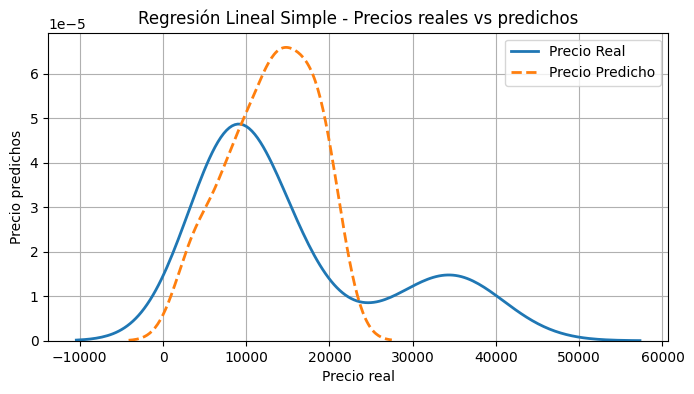

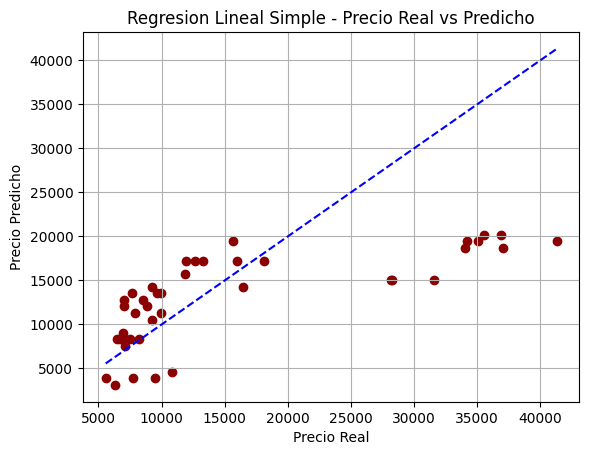

In [13]:
#Comparar precios reales vs predichos
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel('Precio real')
plt.ylabel('Precio predichos')
plt.title('Regresión Lineal Simple - Precios reales vs predichos')
plt.grid(True)
plt.legend()
plt.show()

plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresion Lineal Simple - Precio Real vs Predicho")
plt.grid(True)
plt.show()